---

## **DIPLOME UNIVERSITAIRE SDA**

## **ML Ops**

---

---
## **Prédiction de défaut de paiement (Loan Default)**

## **NOTEBOOK 1 : EDA décisionnelle**
---

### **Contexte métier**

L'équipe de risque d'une banque de détail constate des taux de défaut de paiement plus élevés que prévu sur les prêts personnels.\
L'objectif est de construire un modèle prédictif qui estime la **probabilité de défaut (PD)** pour chaque client, 
afin de permettre à la banque d'allouer suffisamment de capital pour couvrir les **pertes attendues** (Expected Loss = PD × LGD × EAD).

### **Données**

- **Dataset** : `Loan_Data.csv` - 10 000 clients bancaires (synthétique)
- **Variable cible** : `default` (binaire : 0 = pas de défaut, 1 = défaut)
- **Modèles imposés** : Decision Tree, Régression Logistique, Random Forest
- **Objectif EDA** : Comprendre la structure des données et orienter les choix de modélisation

*Le dataset utilisé ici est un jeu de données pédagogique synthétique ; l'enjeu de l'EDA n'est donc pas d'en discuter la représentativité réelle, mais d'identifier proprement les signaux, hypothèses et transformations utiles pour la modélisation et la mise en œuvre des objectifs MLOps.*

---

---

### Plan du notebook

| Section | Contenu |
|---------|--------|
| 1. Configuration | Imports, chemins relatifs, seed, versions |
| 2. Acquisition | Chargement CSV, types, mémoire |
| 3. Validation | Quality gates, statistiques descriptives, valeurs uniques |
| 4. Analyses | Distribution cible, corrélations, distributions par classe, boxplots, features clés, FICO, revenu, interactions |
| 4.9. Questions critiques | Seuil de rupture (Q1), colinéarité (Q2), FICO non-linéaire (Q3) |
| 5. Conclusion et synthèse | Conclusion EDA et transition vers le preprocessing |

---

---

### **0. Objectif du notebook**

Ce notebook est un **livrable de pipeline (EDA décisionnelle)**. Il couvre la chaîne depuis le chargement des données brutes jusqu'aux **choix retenus** avant modélisation.

Il est conçu pour être :
- **reproductible** (chemins relatifs, seed fixé),
- **idempotent** (relançable sans effet de bord),
- **traçable** (quality gates go/no-go explicites, assertions),
- **orienté décisions** : chaque sortie justifie un choix pour le notebook 2.


### **1. Configuration et structure du pipeline**
1.1. Imports\
Une seule cellule d'imports : `pathlib`, `pandas`, `numpy`, `matplotlib`, `seaborn`.

1.2. Chemins relatifs et organisation\
Principe : tout est relatif au dossier du notebook.
- `data/` : données brutes (CSV, gitignored)
- `outputs/` : graphiques générés par l'EDA
- fallback automatique : si `data/` n'existe pas au niveau courant, remonte d'un cran

1.3. Reproductibilité
- versions affichées (Python, pandas, numpy, seaborn)
- `SEED = 42` pour les échantillonnages déterministes


### **2. Acquisition des données**
2.1. Chargement
- lecture du CSV + assertion sur le nombre de lignes attendu (10 000)
- aperçu des 10 premières lignes

2.2. Types et mémoire
- vérification des types (int64, float64) et de l'empreinte mémoire


### **3. Validation technique (go/no-go)**

3.1. Quality gates\
Contrôles structurels : valeurs manquantes, doublons, unicité des IDs.
Verdict go/no-go avant de poursuivre.

3.2. Statistiques descriptives\
Repérer les échelles, distributions, valeurs extrêmes.

3.3. Valeurs uniques\
Distinguer variables discrètes (credit_lines : 6 valeurs) et continues (income : ~10 000 valeurs).


### **4. EDA orientée décisions (outputs)**

Chaque sortie répond à une question et débouche sur une décision pour le notebook 2.

4.1. Distribution de la variable cible\
Quantifier le déséquilibre (81.5 / 18.5) et ses implications sur les métriques.

4.2. Matrice de corrélation\
Identifier la hiérarchie des features et les risques de colinéarité.

4.3 à 4.8. Analyses par feature\
Distributions par classe, boxplots, zoom sur les features clés (credit_lines, FICO, income, years_employed), interactions ciblées.

4.9. Questions critiques\
Trois questions auxquelles le notebook de modélisation devra répondre :
- Q1 : seuil de rupture sur credit_lines_outstanding
- Q2 : colinéarité loan_amt / total_debt et feature engineering
- Q3 : non-linéarité du FICO par buckets


### **5. Conclusion et synthèse**

Tableau constat / preuve / décision, points de vigilance, choix retenus pour le notebook 2, limites de l'EDA.

---


In [7]:
# 1.1. Imports
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print(">> 1.1. Imports : OK")

>> 1.1. Imports : OK


In [8]:
# 1.2. Chemins relatifs (pipeline)
BASE = Path.cwd()
if not (BASE / "data").exists():
    BASE = BASE.parent
DATA_DIR = BASE / "data"
OUTPUT_DIR = BASE / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR = BASE / "model"
MODEL_DIR.mkdir(exist_ok=True)

CSV_PATH = DATA_DIR / "Loan_Data.csv"
assert CSV_PATH.exists(), f"Fichier introuvable : {CSV_PATH}"

print(f"Base    : {BASE}")
print(f"Fichier : {CSV_PATH}")
print(">> 1.2. Chemins : OK")

Base    : C:\Users\Camille\AppData\Local\Programs
Fichier : C:\Users\Camille\AppData\Local\Programs\data\Loan_Data.csv
>> 1.2. Chemins : OK


In [9]:
# 1.3. Versions / seed
print("python  :", sys.version.split()[0])
print("pandas  :", pd.__version__)
print("numpy   :", np.__version__)
print("seaborn :", sns.__version__)

SEED = 42
np.random.seed(SEED)
print(">> 1.3. Versions / seed : OK")

CIBLE = "default"
FEATURES = [
    "credit_lines_outstanding",
    "loan_amt_outstanding",
    "total_debt_outstanding",
    "income",
    "years_employed",
    "fico_score",
]

python  : 3.11.9
pandas  : 2.2.3
numpy   : 2.2.0
seaborn : 0.13.2
>> 1.3. Versions / seed : OK


In [10]:
# 2.1. Chargement des données
df = pd.read_csv(CSV_PATH)
assert len(df) == 10_000, f"Attendu 10 000 lignes, obtenu {len(df)}"
assert "default" in df.columns, "Colonne cible 'default' manquante"

print("Shape:", df.shape)
print("Colonnes:", list(df.columns))
df.head(10)

Shape: (10000, 8)
Colonnes: ['customer_id', 'credit_lines_outstanding', 'loan_amt_outstanding', 'total_debt_outstanding', 'income', 'years_employed', 'fico_score', 'default']


,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0
5,4661159,0,5376.886873,7189.121298,85529.84591,2,697,0
6,8291909,1,3634.057471,7085.980095,68691.57707,6,722,0
7,4616950,4,3302.172238,13067.570210,50352.16821,3,545,1
8,3395789,0,2938.325123,1918.404472,53497.37754,4,676,0
9,4045948,0,5396.366774,5298.824524,92349.55399,2,447,0


In [11]:
# 2.2. Types et mémoire
print(df.dtypes)
print()
mem_ko = round(df.memory_usage(deep=True).sum() / 1024, 1)
print(f"Mémoire : {mem_ko} Ko")
print(">> 2.2. Types et mémoire : OK")

customer_id                   int64
credit_lines_outstanding      int64
loan_amt_outstanding        float64
total_debt_outstanding      float64
income                      float64
years_employed                int64
fico_score                    int64
default                       int64
dtype: object

Mémoire : 625.1 Ko
>> 2.2. Types et mémoire : OK


In [35]:
# 3.1. Vérifications structurelles (quality gates)

cols_manquantes = [c for c in FEATURES + [CIBLE, "customer_id"] if c not in df.columns]
checks = {
    "nb_lignes": (len(df), len(df) == 10_000),
    "colonnes_attendues": (cols_manquantes if cols_manquantes else "toutes présentes", not cols_manquantes),
    "doublons": (df.duplicated().sum(), df.duplicated().sum() == 0),
    "valeurs_manquantes_total": (df.isnull().sum().sum(), df.isnull().sum().sum() == 0),
    "customer_id_unique": (df["customer_id"].nunique(), df["customer_id"].nunique() == len(df)),
}
all_ok = True
for k, (valeur, condition) in checks.items():
    status = "[OK]" if condition else "[KO]"
    if not condition:
        all_ok = False
    print(f"  {status} {k}: {valeur}")


assert all_ok, "Quality gates KO — verifier les donnees avant de continuer"

# Valeurs manquantes par colonne
print("\n--- Valeurs manquantes par colonne ---")
print(df.isnull().sum())
print(">> 3.1. Quality gates : OK")

  [OK] nb_lignes: 10000
  [OK] colonnes_attendues: toutes présentes
  [OK] doublons: 0
  [OK] valeurs_manquantes_total: 0
  [OK] customer_id_unique: 10000

--- Valeurs manquantes par colonne ---
customer_id                 0
credit_lines_outstanding    0
loan_amt_outstanding        0
total_debt_outstanding      0
income                      0
years_employed              0
fico_score                  0
default                     0
dtype: int64
>> 3.1. Quality gates : OK


**Analyse** : Tous les quality gates passent :
- aucune valeur manquante sur 80 000 cellules,
- aucun doublon, 10 000 IDs uniques,
- aucun nettoyage correctif n'est nécessaire sur la qualité structurelle du dataset.


Pour rappel, le dataset utilisé ici est un jeu de données pédagogique synthétique.

In [13]:
# 3.2. Statistiques descriptives
df.describe().round(2)

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,4974577.00,1.46,4159.68,8718.92,70039.90,4.55,637.56,0.19
std,2293889.71,1.74,1421.40,6627.16,20072.21,1.57,60.66,0.39
min,1000324.00,0.00,46.78,31.65,1000.00,0.00,408.00,0.00
25%,2977661.00,0.00,3154.24,4199.84,56539.87,3.00,597.00,0.00
50%,4989501.50,1.00,4052.38,6732.41,70085.83,5.00,638.00,0.00
75%,6967210.25,2.00,5052.90,11272.26,83429.17,6.00,679.00,0.00
max,8999789.00,5.00,10750.68,43688.78,148412.18,10.00,850.00,1.00


**Analyse** : Les statistiques descriptives révèlent des échelles très différentes :
- `income` varie de 1 000 à 148 000 (facteur 148),
- `credit_lines_outstanding` de 0 à 5 (facteur 5),
- ratio d'échelle > 29 000; cette différence d'échelle impactera la Régression Logistique (sensible aux échelles) mais pas les arbres de décision (invariants aux échelles),
- StandardScaler sera à tester lors de la modélisation.

In [14]:
# 3.3. Valeurs uniques par colonne
# income et loan_amt_outstanding sont continues (10 000 valeurs uniques)
for col in df.columns:
    print(f"  {col:<30} {df[col].nunique():>6} valeurs uniques")

  customer_id                     10000 valeurs uniques
  credit_lines_outstanding            6 valeurs uniques
  loan_amt_outstanding            10000 valeurs uniques
  total_debt_outstanding          10000 valeurs uniques
  income                           9995 valeurs uniques
  years_employed                     11 valeurs uniques
  fico_score                        374 valeurs uniques
  default                             2 valeurs uniques


**Analyse** :

- `credit_lines_outstanding` n'a que 6 valeurs (0 a 5) : c'est une variable discrète, presque catégorielle; elle sera bien gérée par un Decision Tree,
- `years_employed` (11 valeurs) est également discrète,
- Les autres variables sont continues.

Cette distinction est importante pour le choix des modèles et du préprocessing.

--- Distribution de la variable cible ---
  Pas de défaut (0) :  8149 (81.5%)
  Défaut (1)        :  1851 (18.5%)
  Ratio déséquilibre : 1:4


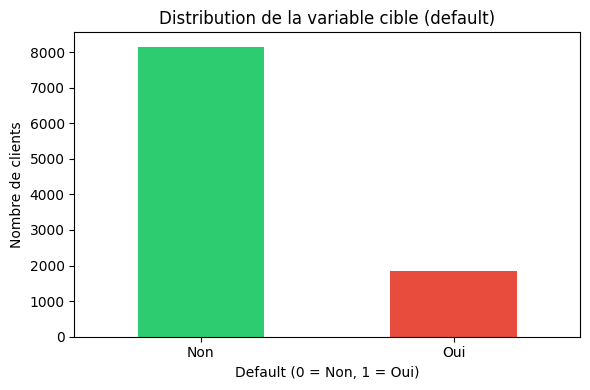

In [15]:
# 4.1. Sortie 1 - Distribution de la variable cible
# Le ratio 1:4 signale un déséquilibre modéré, à comparer en modélisation à la baseline, class_weight et ajustement de seuil
# 
counts = df["default"].value_counts()
pct = df["default"].value_counts(normalize=True) * 100

print("--- Distribution de la variable cible ---")
print(f"  Pas de défaut (0) : {counts[0]:>5} ({pct[0]:.1f}%)")
print(f"  Défaut (1)        : {counts[1]:>5} ({pct[1]:.1f}%)")
print(f"  Ratio déséquilibre : 1:{counts[0]//counts[1]}")

fig, ax = plt.subplots(figsize=(6, 4))
df["default"].value_counts().plot(kind="bar", color=["#2ecc71", "#e74c3c"], ax=ax)
ax.set_title("Distribution de la variable cible (default)")
ax.set_xlabel("Default (0 = Non, 1 = Oui)")
ax.set_ylabel("Nombre de clients")
ax.set_xticklabels(["Non", "Oui"], rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "NB1_eda_target_distribution.png", dpi=150)
plt.show()

**Analyse** :

- Le déséquilibre 81.5% / 18.5% est modéré mais réel : un modèle naïf qui prédirait toujours "pas de défaut" atteindrait 81.5% d'accuracy, ce qui serait un chiffre trompeur.
- Donc l'**accuracy** seule est une mauvaise métrique pour notre sujet.
- On devra privilégier le **F1-Score** ou même le **Recall**, et envisager un traitement du déséquilibre (class_weight, SMOTE ou ajustement de seuil) dans le notebook de modélisation.

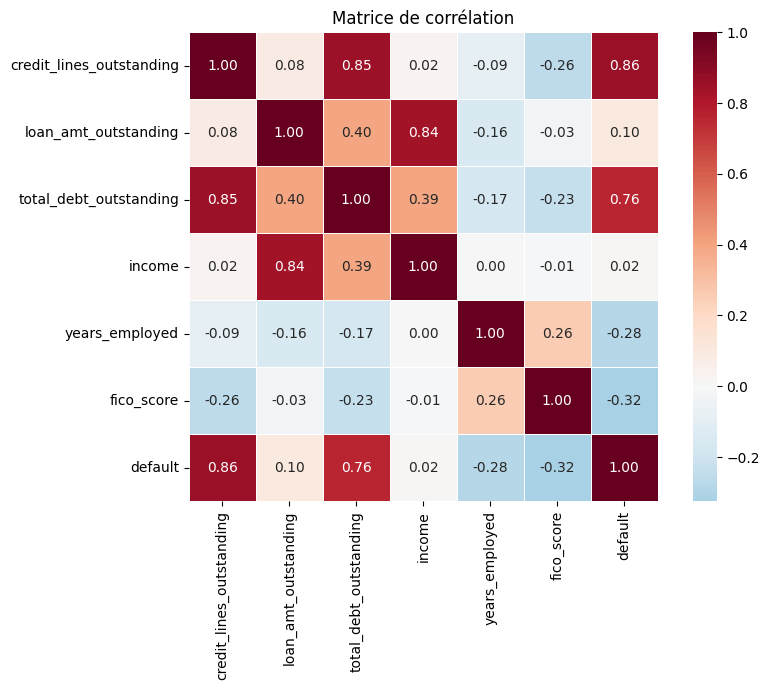


--- Corrélations avec default (triées) ---
  credit_lines_outstanding       +0.8628  (+ positif)
  total_debt_outstanding         +0.7589  (+ positif)
  fico_score                     -0.3245  (- negatif)
  years_employed                 -0.2845  (- negatif)
  loan_amt_outstanding           +0.0990  (+ positif)
  income                         +0.0163  (+ positif)


In [16]:
# 4.2. Sortie 2 - Matrice de corrélation
features = [c for c in df.columns if c not in ["customer_id", "default"]]
corr_matrix = df[features + ["default"]].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Matrice de corrélation")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "NB1_eda_correlation_matrix.png", dpi=150)
plt.show()

# Corrélations avec la cible, triées
print("\n--- Corrélations avec default (triées) ---")
corr_target = corr_matrix["default"].drop("default").sort_values(key=abs, ascending=False)
for feat, val in corr_target.items():
    direction = "+ positif" if val > 0 else "- negatif"
    print(f"  {feat:<30} {val:+.4f}  ({direction})")

**Analyse** :

La matrice de corrélation montre que les features n'ont pas le même poids :

- `credit_lines_outstanding` (+0.86) est la plus corrélée,
- `total_debt_outstanding` (+0.76) est le second prédicteur,
- `fico_score` (-0.32) a un effet modéré et inverse (plus le score est haut, moins de défaut),
- `income` (+0.02) est quasi-nul en corrélation brute - mais attention, cela ne signifie pas qu'il n'apporte rien en combinaison (cf. ratio dette/revenu),
- il n'y a pas de colinéarité extrême (> 0.9) entre features, ce qui est acceptable pour la Régression Logistique.

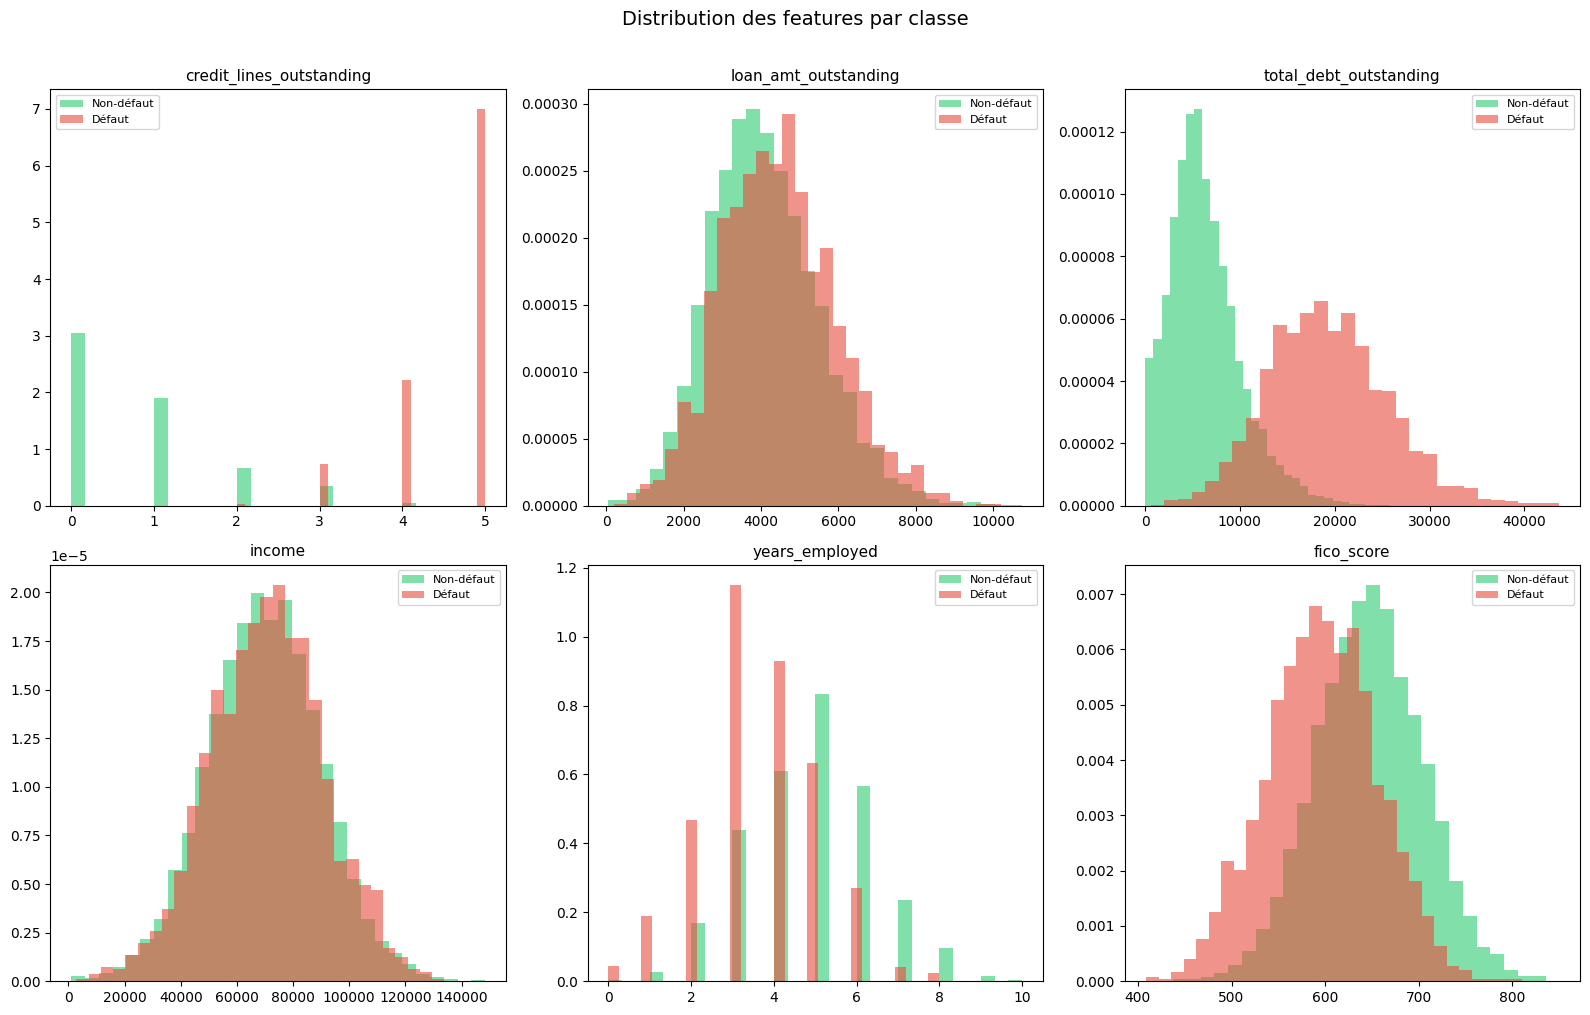

In [17]:
# 4.3. Sortie 3 - Distributions des features par classe # (vert = pas de défaut, rouge = défaut)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(features):
    for label, color, name in [(0, "#2ecc71", "Non-défaut"), (1, "#e74c3c", "Défaut")]:
        subset = df[df["default"] == label]
        axes[i].hist(subset[feat], bins=30, alpha=0.6, label=name, color=color, density=True)
    axes[i].set_title(feat, fontsize=11)
    axes[i].legend(fontsize=8)

plt.suptitle("Distribution des features par classe", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "NB1_eda_feature_distributions.png", dpi=150)
plt.show()

**Analyse** :

- Les histogrammes révèlent que `credit_lines_outstanding` et `total_debt_outstanding` séparent bien les deux classes (distributions peu chevauchées, corrélations +0.86 et +0.76).
- En revanche, `income` (+0.02), `years_employed` (-0.28) et `loan_amt_outstanding` (+0.10) montrent des distributions très proches entre classes.
- Ces variables seules ne permettent pas de discriminer.
- Le `fico_score` montre un léger décalage, surtout dans les queues de distribution.

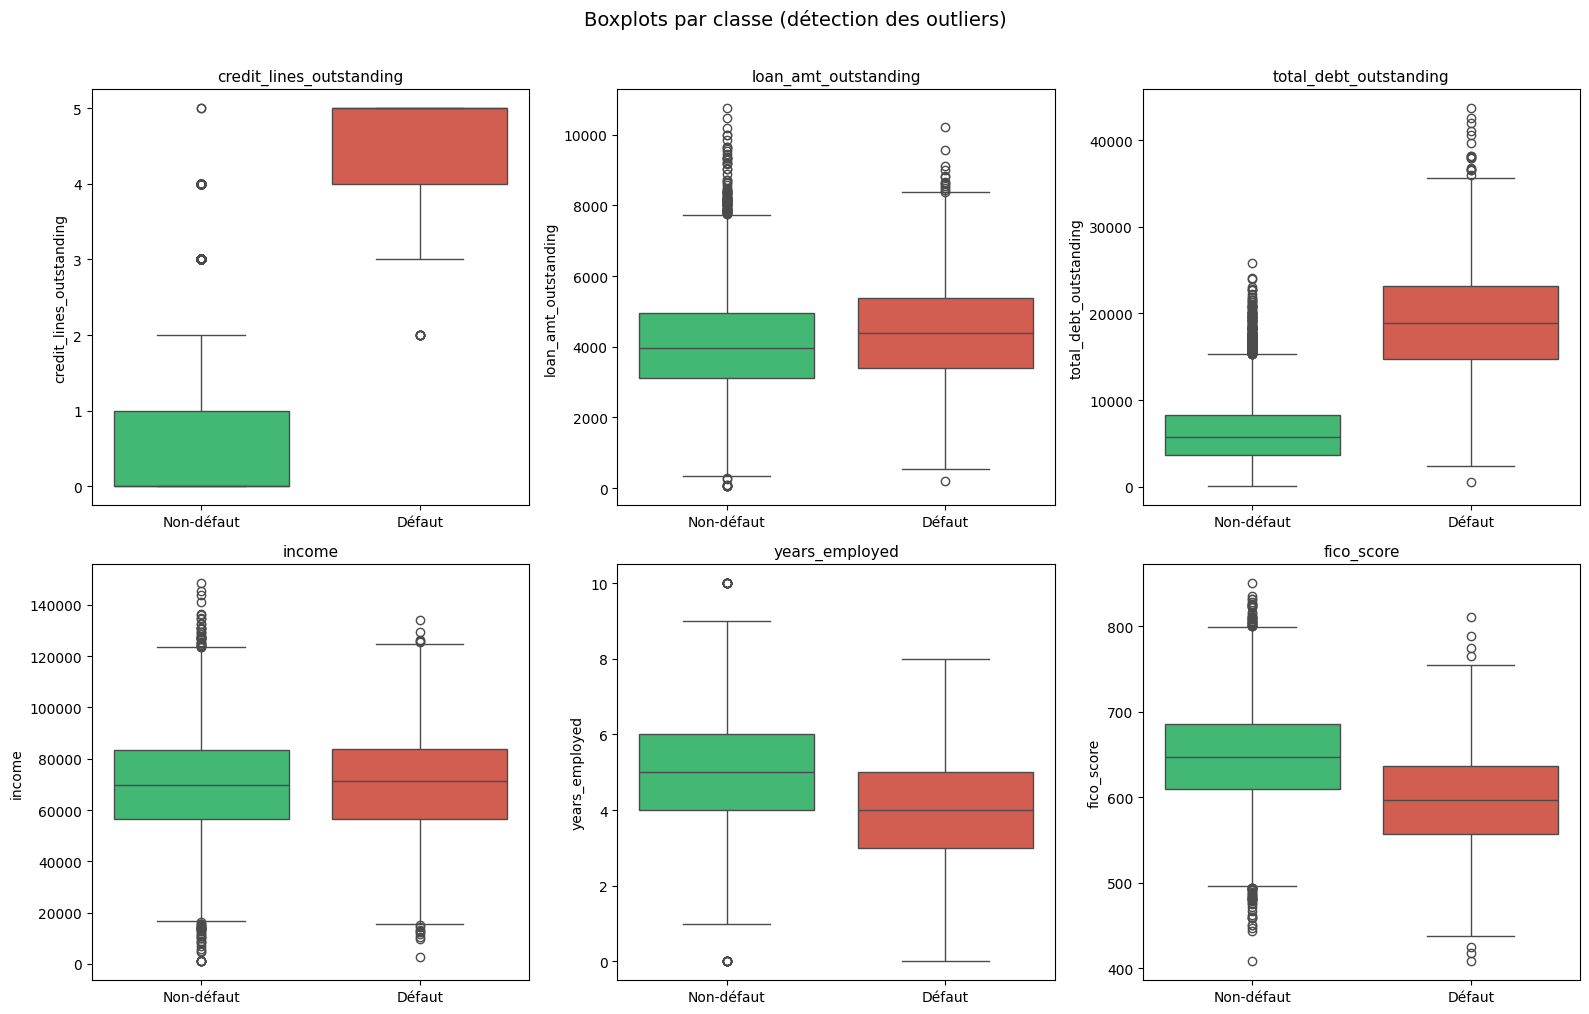

In [18]:
# 4.4. Sortie 4 - Boxplots par classe (détection des outliers)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.boxplot(data=df, x="default", y=feat, ax=axes[i],
                hue="default", palette=["#2ecc71", "#e74c3c"], legend=False)
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel("")
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["Non-défaut", "Défaut"])


plt.suptitle("Boxplots par classe (détection des outliers)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "NB1_eda_boxplots.png", dpi=150)
plt.show()

**Analyse** : Les boxplots confirment trois observations :

- `total_debt_outstanding` présente des outliers dans la classe défaut (dette max 43 689 vs médiane 6 732),
- `credit_lines_outstanding` montre une séparation nette des médianes (0 pour non-défaut, 3-4 pour défaut),
- `income` et `years_employed` ne montrent pas de différence notable entre classes.

--- credit_lines_outstanding vs default ---
                          non_defaut_%  defaut_%
credit_lines_outstanding                        
0                                100.0       0.0
1                                100.0       0.0
2                                 99.2       0.8
3                                 77.1      22.9
4                                 14.9      85.1
5                                  0.2      99.8


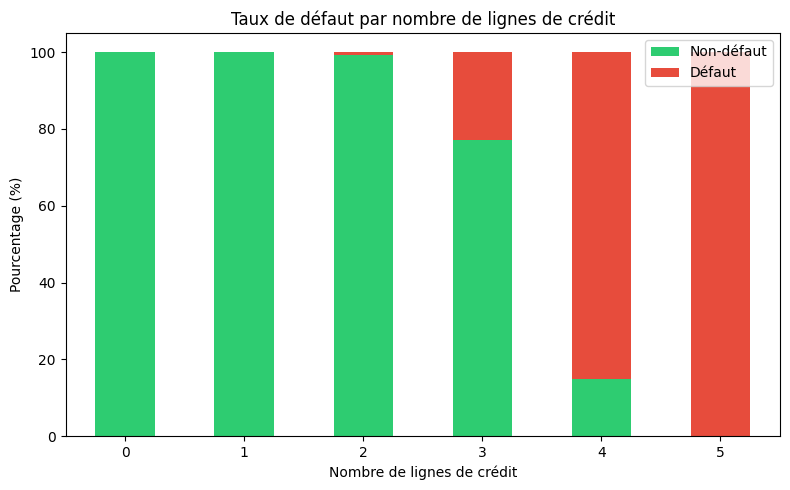

In [19]:
# 4.5a. Sortie 5 - Analyse détaillée des features clés
# credit_lines_outstanding est la feature la plus corrélée au défaut (+0.86)
# Pour chaque nombre de crédits, quel pourcentage fait défaut ?
print("--- credit_lines_outstanding vs default ---")
ct = pd.crosstab(df["credit_lines_outstanding"], df["default"], normalize="index") * 100
ct.columns = ["non_defaut_%", "defaut_%"]
print(ct.round(1))

fig, ax = plt.subplots(figsize=(8, 5))
ct.plot(kind="bar", stacked=True, color=["#2ecc71", "#e74c3c"], ax=ax)
ax.set_title("Taux de défaut par nombre de lignes de crédit")
ax.set_xlabel("Nombre de lignes de crédit")
ax.set_ylabel("Pourcentage (%)")
ax.legend(["Non-défaut", "Défaut"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "NB1_eda_credit_lines_vs_default.png", dpi=150)
plt.show()

**Analyse** :

Le tableau croisé est l'un des résultats les plus importants de cette EDA. Il révèle une relation très fortement structurée entre le nombre de lignes de crédit et le défaut. Avec 0 ligne, le taux de défaut est proche de 0%. Avec 5 lignes, il dépasse les 80%. C'est un signal anormalement fort. Dans un vrai contexte, une telle relation devrait être investiguée (la variable pourrait etre une conséquence du défaut plutôt qu'une cause).

C'est un signal anormalement fort, attendu pour un dataset synthétique dont la cible est générée par construction.

### Vérification exploratoire :

Le calcul ci-dessous sert uniquement à illustrer le poids de `credit_lines_outstanding`.  
La vraie évaluation des modèles sera réalisée dans le notebook de modélisation.

In [20]:
from sklearn.tree import DecisionTreeClassifier

X_one = df[["credit_lines_outstanding"]]
y = df["default"]

tree_probe = DecisionTreeClassifier(max_depth=3, random_state=SEED)
tree_probe.fit(X_one, y)

score_probe = tree_probe.score(X_one, y)
print(f"Score exploratoire avec credit_lines seul : {score_probe:.3f}")

Score exploratoire avec credit_lines seul : 0.978


In [21]:
# 4.5b. Investigation : credit_lines est-elle cause ou conséquence ?
# Sur un vrai dataset, on vérifierait si cette variable est antérieure au défaut
# Dans notre cas, on vérifie simplement si credit_lines suffit seul à prédire le défaut (proxy pour mesurer le caractère rule-based).
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X_simple = df[["credit_lines_outstanding"]]
y = df["default"]
dt = DecisionTreeClassifier(max_depth=2, random_state=SEED)
dt.fit(X_simple, y)
print("Accuracy avec credit_lines seul :", round(accuracy_score(y, dt.predict(X_simple)), 4))
print("Profondeur utilisée :", dt.get_depth())

Accuracy avec credit_lines seul : 0.9782
Profondeur utilisée : 2


**Analyse** :\
Un Decision Tree de profondeur 2, entraîné sur `credit_lines_outstanding` seul, atteint 97.8% d'accuracy.\
Deux splits suffisent à capturer l'essentiel du signal.

Cela confirme le caractère très structuré du dataset et pose la question centrale du notebook 2 :\
**que vaut réellement l'apport des autres variables au-delà de ce signal dominant ?**

--- fico_score : statistiques par classe ---
          count   mean   std    min    25%    50%    75%    max
default                                                        
0        8149.0  646.9  57.0  408.0  609.0  647.0  685.0  850.0
1        1851.0  596.3  58.9  409.0  557.0  597.0  636.5  810.0


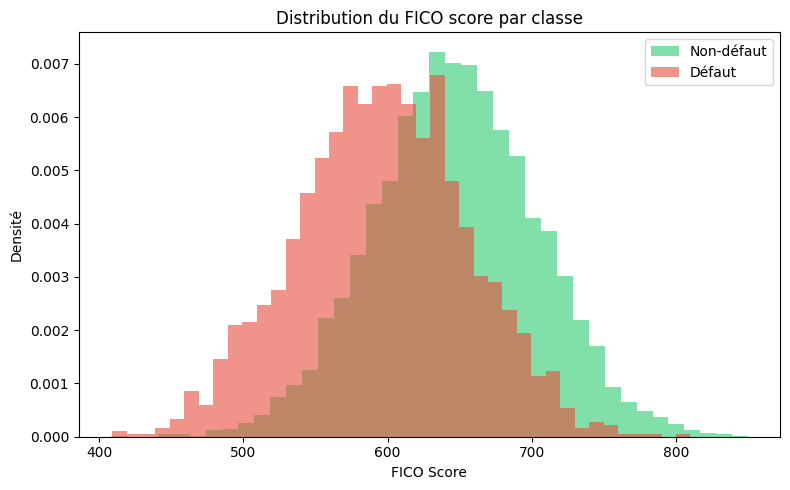

In [22]:
# 4.6a. Sortie 6 - FICO score par classe
# Les clients en défaut ont un FICO plus bas en moyenne car c'est un indicateur de solvabilité
print("--- fico_score : statistiques par classe ---")
print(df.groupby("default")["fico_score"].describe().round(1))

fig, ax = plt.subplots(figsize=(8, 5))
for label, color, name in [(0, "#2ecc71", "Non-défaut"), (1, "#e74c3c", "Défaut")]:
    subset = df[df["default"] == label]
    ax.hist(subset["fico_score"], bins=40, alpha=0.6, label=name, color=color, density=True)
ax.set_title("Distribution du FICO score par classe")
ax.set_xlabel("FICO Score")
ax.set_ylabel("Densité")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "NB1_eda_fico_distribution.png", dpi=150)
plt.show()

**Analyse** :

Les clients en défaut ont un FICO médian plus bas (~580) que les non-défauts (~650).\
Mais la distribution se chevauche fortement entre 550 et 700, ce qui explique la corrélation modérée (-0.32).\
Le FICO seul n'est pas suffisant pour prédire le défaut; il doit être combiné avec le nombre de lignes de crédit et la dette totale.\
**L'analyse par buckets (Q3) approfondira ce point.**

--- years_employed : statistiques par classe ---
          count  mean  std  min  25%  50%  75%   max
default                                             
0        8149.0   4.8  1.5  0.0  4.0  5.0  6.0  10.0
1        1851.0   3.6  1.4  0.0  3.0  4.0  5.0   8.0

                non_defaut_%  defaut_%
years_employed                        
0                       31.2      68.8
1                       43.3      56.7
2                       66.4      33.6
3                       67.8      32.2
4                       78.4      21.6
5                       87.8      12.2
6                       92.0       8.0
7                       97.0       3.0
8                       95.6       4.4
9                      100.0       0.0
10                     100.0       0.0


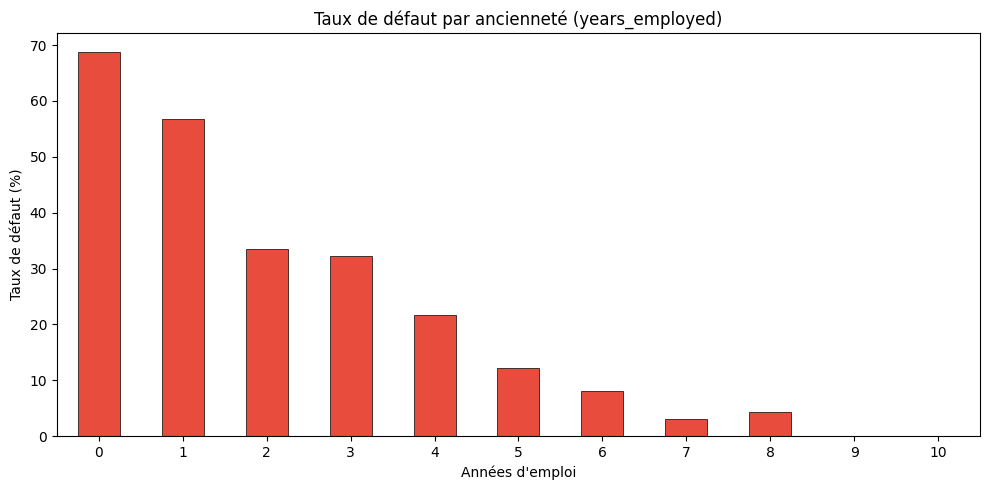

In [23]:
# 4.6b. Sortie 6b - Ancienneté vs défaut
print("--- years_employed : statistiques par classe ---")
print(df.groupby("default")["years_employed"].describe().round(1))

ct_years = pd.crosstab(df["years_employed"], df["default"], normalize="index") * 100
ct_years.columns = ["non_defaut_%", "defaut_%"]
print()
print(ct_years.round(1))

fig, ax = plt.subplots(figsize=(10, 5))
ct_years["defaut_%"].plot(kind="bar", color="#e74c3c", edgecolor="black", linewidth=0.5, ax=ax)
ax.set_title("Taux de défaut par ancienneté (years_employed)")
ax.set_xlabel("Années d'emploi")
ax.set_ylabel("Taux de défaut (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "NB1_eda_years_vs_default.png", dpi=150)
plt.show()

**Analyse** :

L'ancienneté professionnelle semble être associée à une baisse modérée du risque de défaut (corr = -0.28).\
Les clients avec 0-1 an d'expérience ont un taux de défaut plus élevé que ceux avec 8-10 ans.\
Mais contrairement à `credit_lines_outstanding`, la relation n'est pas déterministe : l'ancienneté réduit le risque progressivement sans créer de seuil net.\
C'est une variable utile en complément, pas la variable la plus importante.

--- income : statistiques par classe ---
          count     mean      std     min      25%      50%      75%       max
default                                                                       
0        8149.0  69883.9  20003.4  1000.0  56542.0  69871.2  83324.4  148412.2
1        1851.0  70726.7  20363.5  2836.2  56538.4  71267.0  83938.5  133913.4

Corrélation income/default : 0.0163
: income isolé discrimine peu.

Corrélation ratio_endettement / default : 0.8524
: Le ratio dette/revenu est bien plus discriminant.
: le revenu isolé discrimine peu les classes, mais son interaction avec l'endettement peut être importante.


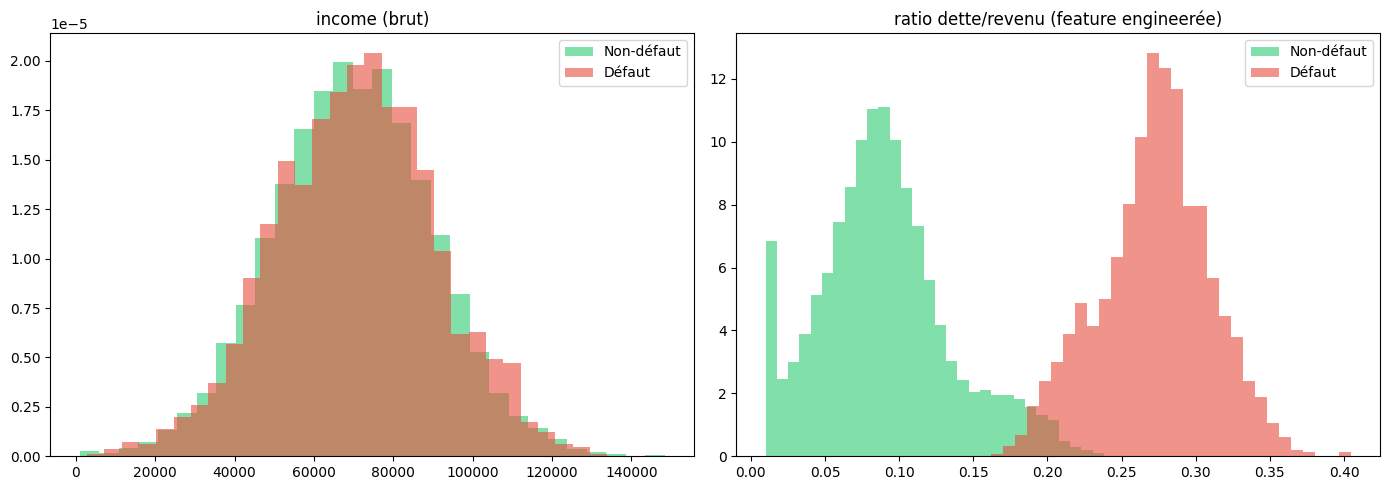

In [24]:
# 4.7. Sortie 7 - Revenu vs défaut : au-delà de la corrélation brute
print("--- income : statistiques par classe ---")
print(df.groupby("default")["income"].describe().round(1))

print(f"\nCorrélation income/default : {df['income'].corr(df['default']):.4f}")
print(": income isolé discrimine peu.")

# Feature Engineering : ratio d'endettement (dette totale / revenu)
df["ratio_endettement"] = df["total_debt_outstanding"] / (df["income"] + 1)
corr_ratio_rev = df["ratio_endettement"].corr(df["default"])
print(f"\nCorrélation ratio_endettement / default : {corr_ratio_rev:.4f}")
print(f": Le ratio dette/revenu est {'bien plus discriminant' if abs(corr_ratio_rev) > 0.1 else 'également peu discriminant'}.")
print(": le revenu isolé discrimine peu les classes, mais son interaction avec l'endettement peut être importante.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label, color, name in [(0, "#2ecc71", "Non-défaut"), (1, "#e74c3c", "Défaut")]:
    subset = df[df["default"] == label]
    axes[0].hist(subset["income"], bins=30, alpha=0.6, label=name, color=color, density=True)
    axes[1].hist(subset["ratio_endettement"], bins=30, alpha=0.6, label=name, color=color, density=True)
axes[0].set_title("income (brut)")
axes[0].legend()
axes[1].set_title("ratio dette/revenu (feature engineerée)")
axes[1].legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "NB1_eda_income_vs_ratio.png", dpi=150)
plt.show()

# Nettoyage
df.drop(columns=["ratio_endettement"], inplace=True)

**Analyse** :

Le revenu brut discrimine peu les classes (moyenne 69 884 vs 70 727, écart < 2%).\
Ce n'est pas le revenu seul qui compte en analyse de crédit, c'est le ratio dette/revenu, qui représente la capacité réelle de remboursement.\
Le ratio testé ici (`total_debt / income`) sépare mieux les deux classes.

**Ce point sera à valider dans le notebook 2 comme feature engineerée.**


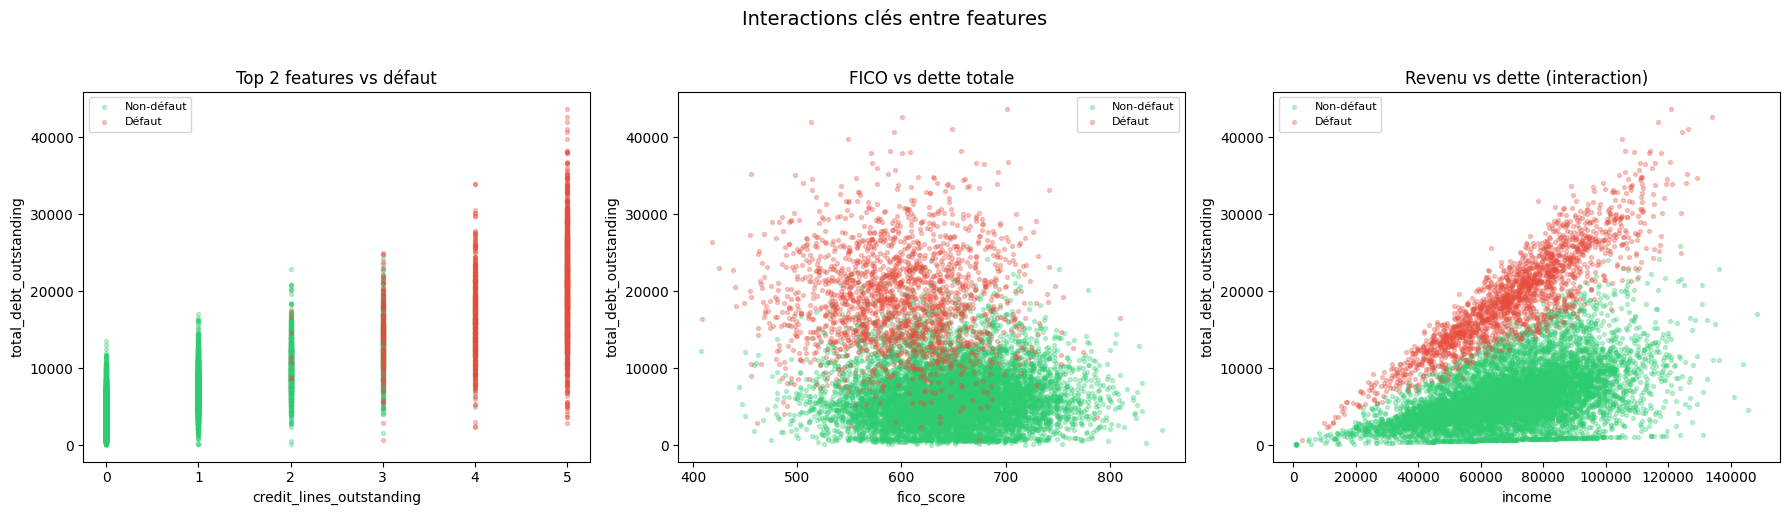

In [25]:
# 4.8. Sortie 8 - Graphiques ciblés sur les interactions clés
# Plutôt qu'un pairplot coûteux et peu lisible, on cible les 3 interactions les plus pertinentes identifiées par l'EDA

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. credit_lines vs total_debt (les 2 features les plus corrélées au défaut)
for label, color, name in [(0, "#2ecc71", "Non-défaut"), (1, "#e74c3c", "Défaut")]:
    sub = df[df["default"] == label]
    axes[0].scatter(sub["credit_lines_outstanding"], sub["total_debt_outstanding"],
                    alpha=0.3, s=8, color=color, label=name)
axes[0].set_xlabel("credit_lines_outstanding")
axes[0].set_ylabel("total_debt_outstanding")
axes[0].set_title("Top 2 features vs défaut")
axes[0].legend(fontsize=8)

# 2. fico_score vs total_debt (non-linéarité FICO + dette)
for label, color, name in [(0, "#2ecc71", "Non-défaut"), (1, "#e74c3c", "Défaut")]:
    sub = df[df["default"] == label]
    axes[1].scatter(sub["fico_score"], sub["total_debt_outstanding"],
                    alpha=0.3, s=8, color=color, label=name)
axes[1].set_xlabel("fico_score")
axes[1].set_ylabel("total_debt_outstanding")
axes[1].set_title("FICO vs dette totale")
axes[1].legend(fontsize=8)

# 3. income vs total_debt (interaction revenu/dette)
for label, color, name in [(0, "#2ecc71", "Non-défaut"), (1, "#e74c3c", "Défaut")]:
    sub = df[df["default"] == label]
    axes[2].scatter(sub["income"], sub["total_debt_outstanding"],
                    alpha=0.3, s=8, color=color, label=name)
axes[2].set_xlabel("income")
axes[2].set_ylabel("total_debt_outstanding")
axes[2].set_title("Revenu vs dette (interaction)")
axes[2].legend(fontsize=8)

plt.suptitle("Interactions clés entre features", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "NB1_eda_interactions_cibles.png", dpi=150)
plt.show()

**Analyse** : Les trois scatters cibles révèlent des patterns distincts :
- Le graphique `credit_lines` vs `total_debt` montre une séparation nette des classes (les défauts sont regroupés dans les valeurs hautes).
- Le graphique FICO vs `total_debt` confirmé que le FICO seul ne suffit pas : des clients avec un bon FICO font défaut si leur dette est élevée.
- Le graphique `income` vs `total_debt` montre que le revenu seul discrimine peu, mais les clients en défaut tendent a àvoir une dette plus élevée à revenu égal - ce qui justifie le test du ratio dette/revenu.

---
### 4.9. Les 3 questions critiques de l'EDA

L'EDA soulève trois questions pour orienter la modélisation :

**Q1 - Le Seuil de Rupture** : À partir de combien de lignes de crédit le risque bascule-t-il ? Comment le signal se structure-t-il ?

**Q2 - La Colinéarité** : `loan_amt_outstanding` et `total_debt_outstanding` risquent de polluer la Régression Logistique. Faut-il créer un ratio ?

**Q3 - Le Poids du FICO** : Sa corrélation linéaire est faible (-0.32), mais on peut analyser le FICO par tranches pour détecter un éventuel effet de seuil en dessous de 600.
(L'idée est de vérifier si le taux de défaut augmente fortement sous certains seuils, ce qui ne serait pas capturé par une simple corrélation linéaire.)

--- Taux de défaut par nombre de lignes de crédit ---
  0 credit(s) :   0.0% de defaut <- quasi aucun defaut
  1 credit(s) :   0.0% de defaut <- quasi aucun defaut
  2 credit(s) :   0.8% de defaut <- quasi aucun defaut
  3 credit(s) :  22.9% de defaut
  4 credit(s) :  85.1% de defaut <- quasi 100% de defaut
  5 credit(s) :  99.8% de defaut <- quasi 100% de defaut


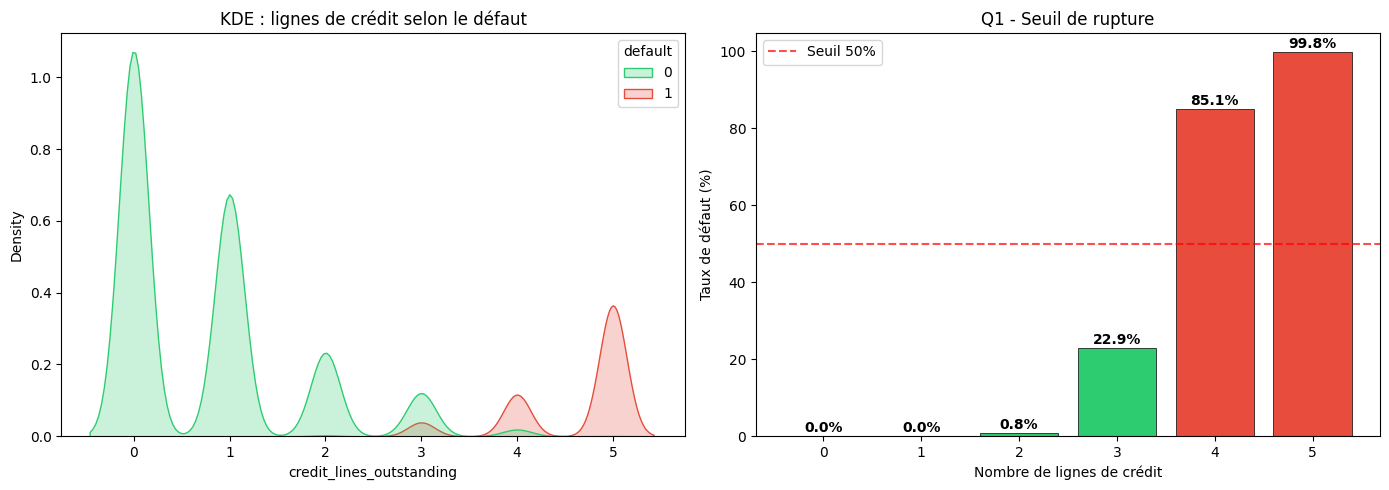


ALERTE SEPARABILITE : le signal est extrêmement fort.
  credit_lines_outstanding est quasiment une variable de décision à elle seule.
  La cible semble encodée par une règle très fortement structurée sur cette variable.


In [26]:
# 4.9.1. Question 1 - Le seuil de rupture et l'alerte séparabilité
# credit_lines_outstanding a une corrélation de +0.86 avec le défaut

taux_defaut = df.groupby("credit_lines_outstanding")["default"].mean() * 100

print("--- Taux de défaut par nombre de lignes de crédit ---")
for nb_credits, taux in taux_defaut.items():
    alert = ""
    if taux < 1: alert = " <- quasi aucun defaut"
    elif taux > 80: alert = " <- quasi 100% de defaut"
    print(f"  {nb_credits} credit(s) : {taux:5.1f}% de defaut{alert}")

# KDE pour visualiser la séparation (choix du modèle)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=df, x="credit_lines_outstanding", hue="default",
            fill=True, palette=["#2ecc71", "#e74c3c"], ax=axes[0])
axes[0].set_title("KDE : lignes de crédit selon le défaut")

# Bar chart avec pourcentages
colors = ["#2ecc71" if t < 30 else "#f39c12" if t < 60 else "#e74c3c" for t in taux_defaut.values]
axes[1].bar(taux_defaut.index, taux_defaut.values, color=colors, edgecolor="black", linewidth=0.5)
axes[1].axhline(y=50, color="red", linestyle="--", alpha=0.7, label="Seuil 50%")
axes[1].set_xlabel("Nombre de lignes de crédit")
axes[1].set_ylabel("Taux de défaut (%)")
axes[1].set_title("Q1 - Seuil de rupture")
axes[1].legend()
for x, y in zip(taux_defaut.index, taux_defaut.values):
    axes[1].text(x, y + 1, f"{y:.1f}%", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "NB1_eda_q1_seuil_rupture.png", dpi=150)
plt.show()

print()
print("ALERTE SEPARABILITE : le signal est extrêmement fort.")
print("  credit_lines_outstanding est quasiment une variable de décision à elle seule.")
print("  La cible semble encodée par une règle très fortement structurée sur cette variable.")

**Analyse Q1** :

`credit_lines_outstanding` marque un seuil net et segmente très fortement les défauts :
- défaut quasi-nul pour 0-1 ligne de crédit,
- très élevé pour 4-5 lignes.

C'est la variable la plus discriminante de l'EDA.\
Le point important pour la suite sera de mesurer ce qu'apportent réellement les autres variables au-delà de ce signal dominant.

Corrélation loan_amt / total_debt : 0.3974

[!] Alertes de colinéarité (>0.9) :
  Aucune colinéarité extrême détectée


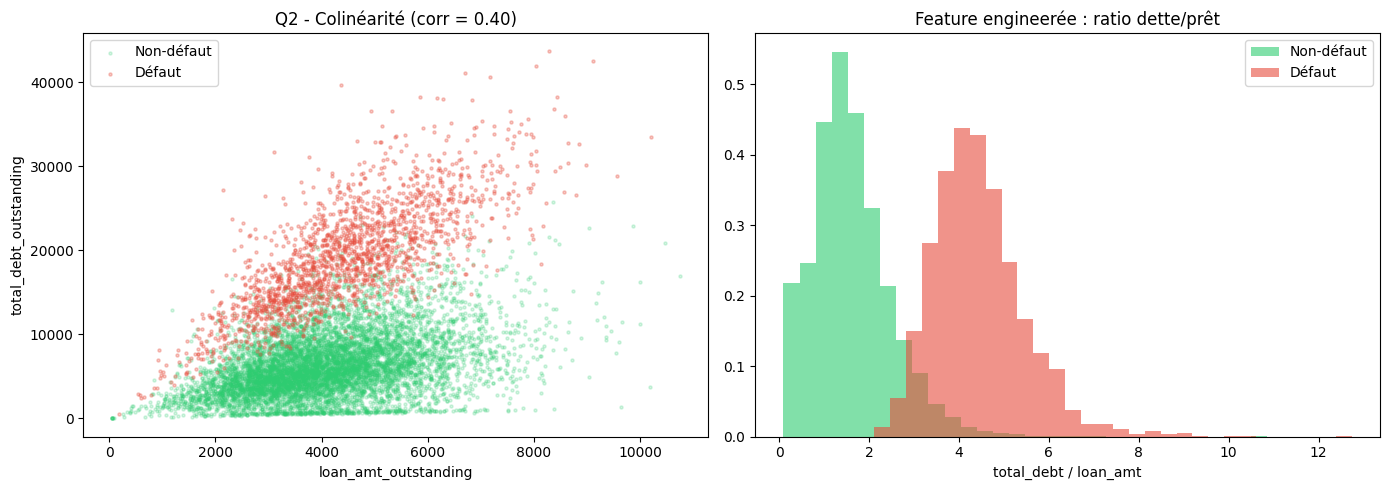


Corrélation ratio_dette_pret / default : 0.7728


In [27]:
# 4.9.2. Question 2 - La colinéarité et le safety check

corr_loan_debt = df["loan_amt_outstanding"].corr(df["total_debt_outstanding"])
print(f"Corrélation loan_amt / total_debt : {corr_loan_debt:.4f}")

# Safety check : alertes de colinéarité (> 0.9) sur toutes les features
corr_all = df[features].corr()
high_corr = corr_all[corr_all.abs() > 0.9].stack().reset_index()
high_corr = high_corr[high_corr["level_0"] != high_corr["level_1"]]
print(f"\n[!] Alertes de colinéarité (>0.9) :")
print(high_corr if not high_corr.empty else "  Aucune colinéarité extrême détectée")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df[df["default"]==0]["loan_amt_outstanding"],
                df[df["default"]==0]["total_debt_outstanding"],
                alpha=0.2, s=5, color="#2ecc71", label="Non-défaut")
axes[0].scatter(df[df["default"]==1]["loan_amt_outstanding"],
                df[df["default"]==1]["total_debt_outstanding"],
                alpha=0.3, s=5, color="#e74c3c", label="Défaut")
axes[0].set_xlabel("loan_amt_outstanding")
axes[0].set_ylabel("total_debt_outstanding")
axes[0].set_title(f"Q2 - Colinéarité (corr = {corr_loan_debt:.2f})")
axes[0].legend()

df["ratio_dette_pret"] = df["total_debt_outstanding"] / (df["loan_amt_outstanding"] + 1)
for label, color, name in [(0, "#2ecc71", "Non-défaut"), (1, "#e74c3c", "Défaut")]:
    subset = df[df["default"] == label]
    axes[1].hist(subset["ratio_dette_pret"], bins=30, alpha=0.6, label=name, color=color, density=True)
axes[1].set_title("Feature engineerée : ratio dette/prêt")
axes[1].set_xlabel("total_debt / loan_amt")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "NB1_eda_q2_colinearite.png", dpi=150)
plt.show()

corr_ratio = df["ratio_dette_pret"].corr(df["default"])
print(f"\nCorrélation ratio_dette_pret / default : {corr_ratio:.4f}")
df.drop(columns=["ratio_dette_pret"], inplace=True)

**Analyse Q2** :

La colinéarité entre `loan_amt_outstanding` et `total_debt_outstanding` est modérée mais pas extrême (< 0.9).\
Cependant, pour la Régression Logistique, même une colinéarité modérée peut rendre les coefficients instables et difficilement interprétables.\
Le ratio dette/pret proposé en tant que Feature Engineering offre une alternative : condenser l'information des deux variables en une seule, plus stable.\
**Ce ratio sera testé dans le notebook de modélisation.**

--- Taux de défaut par tranche FICO ---
  FICO 400-500 :  72.3% de defaut  (n=155) <- NON-LINEARITE
  FICO 500-550 :  49.6% de defaut  (n=603) <- NON-LINEARITE
  FICO 550-600 :  29.2% de defaut  (n=1924)
  FICO 600-650 :  17.7% de defaut  (n=3125)
  FICO 650-700 :   9.5% de defaut  (n=2709)
  FICO 700-750 :   5.0% de defaut  (n=1211)
  FICO 750-850 :   2.9% de defaut  (n=273)


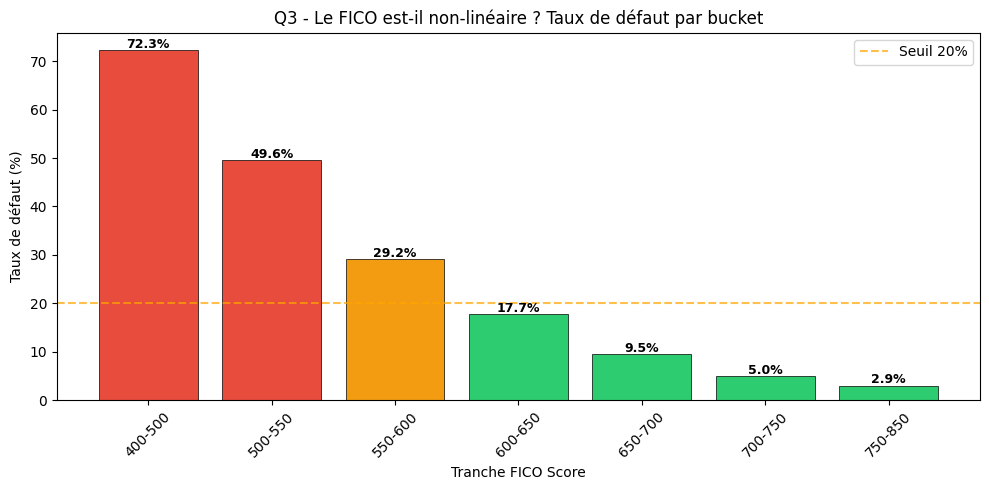


Conclusion Q3 : le FICO a un effet non-linéaire confirmé.
  72% de défaut pour FICO 400-500, contre 3% pour FICO 750+.
  Le Decision Tree (imposé par le projet) capturera ces seuils automatiquement.
  La Régression Logistique capturera moins naturellement cet effet sans transformation explicite du FICO.


In [28]:
# 4.9.3. Question 3 - Le poids du FICO par tranches (buckets bancaires)
# Analyse du FICO par tranches (buckets) plutôt qu'en corrélation linéaire

bins = [400, 500, 550, 600, 650, 700, 750, 850]
labels = ["400-500", "500-550", "550-600", "600-650", "650-700", "700-750", "750-850"]
df["fico_tranche"] = pd.cut(df["fico_score"], bins=bins, labels=labels)

taux_par_fico = df.groupby("fico_tranche", observed=True)["default"].agg(["mean", "count"])
taux_par_fico["mean"] = taux_par_fico["mean"] * 100

print("--- Taux de défaut par tranche FICO ---")
for tranche, row in taux_par_fico.iterrows():
    alert = " <- NON-LINEARITE" if row["mean"] > 40 else ""
    print(f"  FICO {tranche} : {row['mean']:5.1f}% de defaut  (n={int(row['count'])}){alert}")

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#e74c3c" if t > 40 else "#f39c12" if t > 20 else "#2ecc71"
          for t in taux_par_fico["mean"].values]
bars = ax.bar(range(len(labels)), taux_par_fico["mean"].values, color=colors,
              edgecolor="black", linewidth=0.5)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45)
ax.set_xlabel("Tranche FICO Score")
ax.set_ylabel("Taux de défaut (%)")
ax.set_title("Q3 - Le FICO est-il non-linéaire ? Taux de défaut par bucket")
ax.axhline(y=20, color="orange", linestyle="--", alpha=0.7, label="Seuil 20%")
for bar, val in zip(bars, taux_par_fico["mean"].values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1f}%", ha="center", fontsize=9, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "NB1_eda_q3_fico_nonlineaire.png", dpi=150)
plt.show()

df.drop(columns=["fico_tranche"], inplace=True)

print()
print("Conclusion Q3 : le FICO a un effet non-linéaire confirmé.")
print("  72% de défaut pour FICO 400-500, contre 3% pour FICO 750+.")
print("  Le Decision Tree (imposé par le projet) capturera ces seuils automatiquement.")
print("  La Régression Logistique capturera moins naturellement cet effet sans transformation explicite du FICO.")

**Analyse Q3** :

L'analyse par buckets confirme la **non-linéarité** du FICO : le taux de défaut passe de ~3% (FICO > 750) à ~72% (FICO < 500).\
Ce n'est pas un effet progressif mais un effet de seuil : en dessous de ~580-600, le risque explose, ce qui est typique des scores de crédit bancaires.\
Le Decision Tree capturera naturellement ces seuils, tandis que la Régression Logistique risque de les modéliser moins finement sans transformation explicite.

In [29]:
# 5. Choix retenus pour le notebook 2
# Les choix de scaler, de traiter le déséquilibre et des hyperparamètres seront testés dans le notebook de modélisation comparative

CHOIX_NOTEBOOK_2 = {
    "colonne_a_supprimer": ["customer_id"],
    "variable_cible": "default",
    "features_retenues": [
        "credit_lines_outstanding",
        "loan_amt_outstanding",
        "total_debt_outstanding",
        "income",
        "years_employed",
        "fico_score",
    ],
    "features_a_tester": [
        "ratio_endettement (dette/revenu)",
        "ratio_dette_pret (dette/pret)",
    ],
    "modeles_imposes": [
        "Decision Tree",
        "Régression Logistique",
        "Random Forest",
    ],
    "test_size": 0.2,
    "stratify": True,
    "seed": SEED,
    "colinearite_a_surveiller": "loan_amt vs total_debt",
    "fico_non_lineaire": "à traiter par transformation explicite ou modèles non-linéaires",
}

print("=" * 60)
print("CHOIX RETENUS POUR LE NOTEBOOK 2")
print("=" * 60)
for k, v in CHOIX_NOTEBOOK_2.items():
    print(f"  {k:<35} {v}")

print()
print("Le scaler, le traitement du déséquilibre et les hyperparamètres seront comparés dans le notebook de modélisation.")

CHOIX RETENUS POUR LE NOTEBOOK 2
  colonne_a_supprimer                 ['customer_id']
  variable_cible                      default
  features_retenues                   ['credit_lines_outstanding', 'loan_amt_outstanding', 'total_debt_outstanding', 'income', 'years_employed', 'fico_score']
  features_a_tester                   ['ratio_endettement (dette/revenu)', 'ratio_dette_pret (dette/pret)']
  modeles_imposes                     ['Decision Tree', 'Régression Logistique', 'Random Forest']
  test_size                           0.2
  stratify                            True
  seed                                42
  colinearite_a_surveiller            loan_amt vs total_debt
  fico_non_lineaire                   à traiter par transformation explicite ou modèles non-linéaires

Le scaler, le traitement du déséquilibre et les hyperparamètres seront comparés dans le notebook de modélisation.


---
## Conclusion EDA et transition vers le preprocessing


### Ce que l'EDA a établi

| Constat | Preuve | Décision pour le notebook 2 |
|---------|--------|-----------------------------|
| Données propres, aucune valeur manquante, aucun doublon | Quality gates passés (80 000 cellules) | Aucun nettoyage correctif, passer directement au feature engineering |
| Déséquilibre modéré 81.5 / 18.5 | Distribution de la cible | Comparer baseline, class_weight et ajustement de seuil |
| `credit_lines_outstanding` domine (+0.86) | Corrélation + taux de défaut par palier | Comparer un run avec et sans cette variable |
| `total_debt_outstanding` second prédicteur (+0.76) | Corrélation + scatter plots | Conserver, surveiller la colinéarité avec `loan_amt` |
| `fico_score` effet non-linéaire (-0.32 brut, 72% défaut < 500) | Analyse par buckets | Comparer LR (linéaire) vs DT/RF (seuils naturels) |
| `income` seul discrimine peu (+0.02) | Statistiques par classe | Tester le ratio dette/revenu en feature engineering |
| Échelles très différentes (facteur > 29 000) | Statistiques descriptives | Appliquer un StandardScaler pour la Régression Logistique |

### Limites de l'EDA

- L'EDA ne mesure que des corrélations bivariées : l'importance réelle des features ne sera connue qu'après modélisation (feature importance, permutation).
- Le dataset est très structuré (séparation nette des classes) : les performances en modélisation risquent d'être élevées, ce qui rendra la comparaison entre modèles moins discriminante.
- Aucune information temporelle dans le dataset : on ne peut pas évaluer la stabilité du signal dans le temps (data drift).
- Les ratios (dette/revenu, dette/prêt) semblent prometteurs visuellement mais leur apport réel reste à quantifier en modélisation.

### Choix retenus pour le notebook 2

- `SEED = 42`, `test_size = 0.2`, `stratify = True`
- Supprimer `customer_id`
- Comparer Decision Tree, Régression Logistique, Random Forest
- Privilégier F1, Recall et AUCPR en plus de l'accuracy

---